In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

# 分析数据

In [3]:
import os

os.listdir(r'Python定量城市研究实战-作业demo\demo数据')

FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'Python定量城市研究实战-作业demo\\demo数据'

In [3]:
shp = gpd.read_file(r'Python定量城市研究实战-作业demo\demo数据\流域数据.shp')

In [4]:
shp.head()

,Join_Count,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,DSNODEID,strmOrder,Length,Magnitude,DSContArea,...,USContArea,WSNO,DOUTEND,DOUTSTART,DOUTMID,ORIG_FID,Shape_Leng,Shape_Area,merge,geometry
0,2,0,-1,-1,-1,-1.0,1,1392.4,1,19360190.0,...,15666163.0,0,0.0,1392.4,696.2,335,0.227894,0.002318,0,"POLYGON ((716390.235 5541363.232, 716259.316 5..."
1,1,1,6481,-1,-1,-1.0,1,1775.2,1,16527133.0,...,15066974.0,1,170015.5,171790.7,170903.1,879,0.213080,0.001971,0,"POLYGON ((470615.358 5504361.109, 470583.279 5..."
2,1,2,6033,-1,-1,-1.0,1,1055.5,1,16992522.0,...,16498046.0,2,14383.3,15438.8,14911.1,503,0.196735,0.002033,0,"POLYGON ((612927.032 5467906.521, 612897.973 5..."
3,1,3,6786,-1,-1,-1.0,1,375.4,1,13781337.0,...,13624268.0,3,44617.4,44992.7,44805.1,1015,0.187610,0.001646,0,"POLYGON ((488384.658 5429964.139, 488350.886 5..."
4,1,4,6596,-1,-1,-1.0,1,30867.4,1,75369776.0,...,13135609.0,4,211904.9,242772.6,227338.7,2377,0.725639,0.008999,0,"POLYGON ((661005.347 5389347.648, 660802.400 5..."


In [5]:
shp.crs

<Projected CRS: EPSG:4546>
Name: CGCS2000 / 3-degree Gauss-Kruger CM 111E
Axis Info [cartesian]:
- X[north]: Northing (metre)
- Y[east]: Easting (metre)
Area of Use:
- name: China - 109.5°E to 112.5°E onshore
- bounds: (109.5, 18.11, 112.5, 45.11)
Coordinate Operation:
- name: Gauss-Kruger CM 111E
- method: Transverse Mercator
Datum: China 2000
- Ellipsoid: CGCS2000
- Prime Meridian: Greenwich

In [6]:
shp.columns

Index(['Join_Count', 'LINKNO', 'DSLINKNO', 'USLINKNO1', 'USLINKNO2',
       'DSNODEID', 'strmOrder', 'Length', 'Magnitude', 'DSContArea',
       'strmDrop', 'Slope', 'StraightL', 'USContArea', 'WSNO', 'DOUTEND',
       'DOUTSTART', 'DOUTMID', 'ORIG_FID', 'Shape_Leng', 'Shape_Area', 'merge',
       'geometry'],
      dtype='object')

In [7]:
shp_a = shp[['LINKNO', 'DSLINKNO', 'USLINKNO1', 'USLINKNO2', 'geometry']]

In [8]:
shp_a

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,geometry
0,0,-1,-1,-1,"POLYGON ((716390.235 5541363.232, 716259.316 5..."
1,1,6481,-1,-1,"POLYGON ((470615.358 5504361.109, 470583.279 5..."
2,2,6033,-1,-1,"POLYGON ((612927.032 5467906.521, 612897.973 5..."
3,3,6786,-1,-1,"POLYGON ((488384.658 5429964.139, 488350.886 5..."
4,4,6596,-1,-1,"POLYGON ((661005.347 5389347.648, 660802.400 5..."
...,...,...,...,...,...
8796,10297,10313,10281,969,"POLYGON ((786261.652 5229494.433, 786160.818 5..."
8797,10301,10317,10285,557,"POLYGON ((426438.630 5085361.583, 426602.934 5..."
8798,10313,-1,10297,361,"POLYGON ((787245.988 5230099.193, 787208.357 5..."
8799,10317,-1,10301,3260,"POLYGON ((425785.277 5084813.557, 425755.941 5..."


In [9]:
shp_a['area'] = shp_a.area / 1000000

C:\Users\think\anaconda3\lib\site-packages\geopandas\geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


shp_a

# sample

## 第一步：获取流域列表

In [6]:
dt = [[525,2557,-1,-1,],[621,2557,-1,-1,],[2557,-1,529,621,],[3356,-1,655,555,],[3156,-1,655,555,]]
ar = gpd.GeoDataFrame(dt,columns=['LINKNO','DSLINKNO','USLINKNO1','USLINKNO2'])

In [4]:
dt = gpd.read_file(r'C:\Users\SLL\Desktop\test\子流域合并\子流域.shp')
ar = gpd.GeoDataFrame(dt,columns=['LINKNO', 'DSLINKNO', 'USLINKNO1', 'USLINKNO2','strmOrder', 'geometry'])

In [5]:
ar

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3..."
1,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3..."
2,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915..."
3,3150,7646,-1,-1,2,"POLYGON ((376578.340 3920789.419, 376351.239 3..."
4,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3..."
5,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3..."
6,6478,7870,5870,3038,2,"POLYGON ((379034.391 3923253.015, 378807.354 3..."
7,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3..."
8,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3..."
9,7646,7870,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3..."


In [6]:
ar['link'] = ar.apply(lambda x:{int(x[i]) for i in range(4) if x[i] != -1},axis=1)

In [7]:
ar

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry,link
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3...","{5742, 3022}"
1,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3...","{6814, 3118}"
2,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915...","{5742, 3134}"
3,3150,7646,-1,-1,2,"POLYGON ((376578.340 3920789.419, 376351.239 3...","{7646, 3150}"
4,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3...","{7358, 3390}"
5,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3...","{3134, 6814, 3022, 5742}"
6,6478,7870,5870,3038,2,"POLYGON ((379034.391 3923253.015, 378807.354 3...","{3038, 7870, 5870, 6478}"
7,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3...","{3118, 5742, 7358, 6814}"
8,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3...","{3390, 6814, 7646, 7358}"
9,7646,7870,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3...","{3150, 7870, 7358, 7646}"


In [8]:
ar['link'][0] & ar['link'][1]

set()

In [9]:
len(ar['link'][0] & ar['link'][1]) > 0

False

In [10]:
# ar.loc[5]=[1,1,1,1,{3}]

## 算法 - 获取相同的流域

In [11]:
ar

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry,link
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3...","{5742, 3022}"
1,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3...","{6814, 3118}"
2,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915...","{5742, 3134}"
3,3150,7646,-1,-1,2,"POLYGON ((376578.340 3920789.419, 376351.239 3...","{7646, 3150}"
4,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3...","{7358, 3390}"
5,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3...","{3134, 6814, 3022, 5742}"
6,6478,7870,5870,3038,2,"POLYGON ((379034.391 3923253.015, 378807.354 3...","{3038, 7870, 5870, 6478}"
7,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3...","{3118, 5742, 7358, 6814}"
8,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3...","{3390, 6814, 7646, 7358}"
9,7646,7870,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3...","{3150, 7870, 7358, 7646}"


In [12]:
ar['all'] = list([ar['link'].values]) * 10

In [13]:
ar

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry,link,all
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3...","{5742, 3022}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
1,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3...","{6814, 3118}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
2,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915...","{5742, 3134}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
3,3150,7646,-1,-1,2,"POLYGON ((376578.340 3920789.419, 376351.239 3...","{7646, 3150}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
4,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3...","{7358, 3390}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
5,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3...","{3134, 6814, 3022, 5742}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
6,6478,7870,5870,3038,2,"POLYGON ((379034.391 3923253.015, 378807.354 3...","{3038, 7870, 5870, 6478}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
7,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3...","{3118, 5742, 7358, 6814}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
8,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3...","{3390, 6814, 7646, 7358}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."
9,7646,7870,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3...","{3150, 7870, 7358, 7646}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76..."


In [14]:
def get(x):
    base_set = x[0]
    
    for set_n in x[1]:        
        if len(x[0] & set_n) > 0:
            base_set = base_set | set_n
        else:
            pass
    
    return base_set

In [16]:
ar[['link','all']].apply(get,axis=1)

0                 {6814, 5742, 3022, 3118, 7358, 3134}
1     {3390, 7646, 6814, 3022, 3118, 5742, 3134, 7358}
2                 {6814, 5742, 3022, 3118, 7358, 3134}
3                 {7646, 6814, 7870, 3150, 7358, 3390}
4     {7646, 6814, 7870, 3118, 5742, 3150, 7358, 3390}
5     {3390, 7646, 6814, 3022, 5742, 3118, 7358, 3134}
6           {7646, 7870, 5870, 6478, 3150, 7358, 3038}
7    {7646, 6814, 7870, 3022, 3118, 5742, 3150, 313...
8    {3390, 6814, 7870, 3118, 3150, 3022, 5742, 313...
9    {7646, 6814, 7870, 3150, 5870, 6478, 3118, 574...
dtype: object

In [17]:
ar['watershed'] = ar[['link','all']].apply(get,axis=1)

In [18]:
ar

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry,link,all,watershed
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3...","{5742, 3022}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{6814, 5742, 3022, 3118, 7358, 3134}"
1,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3...","{6814, 3118}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{3390, 7646, 6814, 3022, 3118, 5742, 3134, 7358}"
2,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915...","{5742, 3134}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{6814, 5742, 3022, 3118, 7358, 3134}"
3,3150,7646,-1,-1,2,"POLYGON ((376578.340 3920789.419, 376351.239 3...","{7646, 3150}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{7646, 6814, 7870, 3150, 7358, 3390}"
4,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3...","{7358, 3390}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{7646, 6814, 7870, 3118, 5742, 3150, 7358, 3390}"
5,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3...","{3134, 6814, 3022, 5742}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{3390, 7646, 6814, 3022, 5742, 3118, 7358, 3134}"
6,6478,7870,5870,3038,2,"POLYGON ((379034.391 3923253.015, 378807.354 3...","{3038, 7870, 5870, 6478}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{7646, 7870, 5870, 6478, 3150, 7358, 3038}"
7,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3...","{3118, 5742, 7358, 6814}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{7646, 6814, 7870, 3022, 3118, 5742, 3150, 313..."
8,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3...","{3390, 6814, 7646, 7358}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{3390, 6814, 7870, 3118, 3150, 3022, 5742, 313..."
9,7646,7870,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3...","{3150, 7870, 7358, 7646}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{7646, 6814, 7870, 3150, 5870, 6478, 3118, 574..."


In [19]:
{tuple(i) for i in ar['watershed'].values}
# 这里出现问题、第一个元素和第二个元素其实是一样的
# 为什么会出现这个问题？
# 因为集合元素是无序的。

{(3390, 6814, 7870, 3118, 3150, 3022, 5742, 3134, 7358, 7646),
 (3390, 7646, 6814, 3022, 3118, 5742, 3134, 7358),
 (3390, 7646, 6814, 3022, 5742, 3118, 7358, 3134),
 (6814, 5742, 3022, 3118, 7358, 3134),
 (7646, 6814, 7870, 3022, 3118, 5742, 3150, 3134, 7358, 3390),
 (7646, 6814, 7870, 3118, 5742, 3150, 7358, 3390),
 (7646, 6814, 7870, 3150, 5870, 6478, 3118, 5742, 3038, 7358, 3390),
 (7646, 6814, 7870, 3150, 7358, 3390),
 (7646, 7870, 5870, 6478, 3150, 7358, 3038)}

In [20]:
{tuple(sorted(tuple(i))) for i in ar['watershed'].values} # 需要排序一下。

{(3022, 3118, 3134, 3150, 3390, 5742, 6814, 7358, 7646, 7870),
 (3022, 3118, 3134, 3390, 5742, 6814, 7358, 7646),
 (3022, 3118, 3134, 5742, 6814, 7358),
 (3038, 3118, 3150, 3390, 5742, 5870, 6478, 6814, 7358, 7646, 7870),
 (3038, 3150, 5870, 6478, 7358, 7646, 7870),
 (3118, 3150, 3390, 5742, 6814, 7358, 7646, 7870),
 (3150, 3390, 6814, 7358, 7646, 7870)}

In [21]:
ar.dissolve(by = 'strmOrder',)

,geometry,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,link,all,watershed
strmOrder,,,,,,,,
1,"MULTIPOLYGON (((364991.359 3925673.039, 364989...",3022,5742,-1,-1,"{5742, 3022}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{6814, 5742, 3022, 3118, 7358, 3134}"
2,"POLYGON ((369232.677 3920708.404, 368778.461 3...",3118,6814,-1,-1,"{6814, 3118}","[{5742, 3022}, {6814, 3118}, {5742, 3134}, {76...","{3390, 7646, 6814, 3022, 3118, 5742, 3134, 7358}"


In [53]:
boundarys = ar.geometry.unary_union #融合为一行

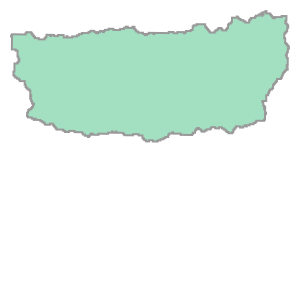

In [54]:
boundarys